# Pilot Study: Clarifying Questions as Signals of Internal Uncertainty

This notebook implements a three-part pilot study testing whether clarifying questions generated by an LLM can help distinguish among three prompt regimes:

- **Epistemic**: the model faces a knowledge gap.
- **Aleatoric**: multiple valid answers exist or more user context is needed.
- **Unambiguous**: a control condition where the model should respond with `NO_CLARIFICATION_NEEDED`.

The workflow is organised into three phases:

1. **Phase 1**: generate one response per prompt and classify the observed uncertainty type.
2. **Phase 2**: generate repeated responses per prompt and quantify variation.
3. **Phase 3**: integrate labels and variation statistics, with the control group analysed separately where relevant.


## Requirements

This notebook uses:

- `pandas`
- `numpy`
- `matplotlib`
- `seaborn`
- `scipy`
- `bert-score`
- `google-generativeai`
- `ipython`

Example install command:

```bash
pip install pandas numpy matplotlib seaborn scipy bert-score google-generativeai ipython
```


In [1]:
from __future__ import annotations

import itertools
import json
import os
import random
import re
import time
from pathlib import Path

import google.generativeai as genai
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from bert_score import score as bertscore_score
from IPython.display import Markdown, display
from scipy.stats import kruskal, mannwhitneyu, pointbiserialr
from google.api_core import exceptions as google_exceptions

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "outputs"
FIGURE_DIR = ROOT / "figures"
PROMPT_TEMPLATE_PATH = ROOT / "gemini_prompt_template.txt"
PROMPTS_JSON_PATH = ROOT / "study_prompts.json"
GENERATED_CQS_PATH = OUTPUT_DIR / "generated_cqs.csv"
LABELLED_CQS_PATH = OUTPUT_DIR / "labelled_cqs.csv"
VARIATION_RUNS_PATH = OUTPUT_DIR / "variation_runs.csv"
VARIATION_SCORES_PATH = OUTPUT_DIR / "variation_scores.csv"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

VALID_TYPES = ["epistemic", "aleatoric", "unambiguous"]
QUESTION_TYPES = ["epistemic", "aleatoric"]
NO_CLARIFICATION_TOKEN = "NO_CLARIFICATION_NEEDED"
GEMINI_MODEL = "gemma-3-4b-it"
PHASE1_GENERATION_CONFIG = {"temperature": 0.0, "top_p": 0.9, "max_output_tokens": 512}
PHASE2_GENERATION_CONFIG = {"temperature": 2.0, "top_p": 1.0, "max_output_tokens": 512}
N_VARIATION_RUNS = 5
REQUEST_INTERVAL_SECONDS = 3.5
MAX_RETRIES = 12

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "savefig.dpi": 300,
    "figure.dpi": 120,
})

PALETTE = {
    "epistemic": "#1f77b4",
    "aleatoric": "#ff7f0e",
    "unambiguous": "#2ca02c",
    True: "#2ca02c",
    False: "#d62728",
    "Agreement": "#2ca02c",
    "Disagreement": "#d62728",
    "Correct": "#2ca02c",
    "Incorrect": "#d62728",
}


def save_and_show(fig: plt.Figure, filename: str) -> None:
    output_path = FIGURE_DIR / filename
    fig.tight_layout()
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()


def clean_text(text: str) -> str:
    if text is None:
        return ""
    return " ".join(str(text).strip().split())


def word_count(text: str) -> int:
    return len(clean_text(text).split())


def response_word_count(text: str) -> int:
    return 0 if clean_text(text) == NO_CLARIFICATION_TOKEN else word_count(text)


def is_no_clarification(text: str) -> bool:
    return clean_text(text).upper().replace(" ", "_") == NO_CLARIFICATION_TOKEN


def validate_labels(series: pd.Series, name: str) -> None:
    observed = set(series.dropna().astype(str).str.strip().str.lower())
    invalid = observed - set(VALID_TYPES)
    if invalid:
        raise ValueError(f"{name} contains invalid labels: {sorted(invalid)}")


def normalize_model_output(text: str) -> str:
    text = clean_text(text)
    if not text:
        return ""
    if NO_CLARIFICATION_TOKEN in text.upper().replace(" ", "_"):
        return NO_CLARIFICATION_TOKEN
    text = re.sub(r"^(clarifying question|question)\s*[:\-]\s*", "", text, flags=re.IGNORECASE)
    text = text.strip(" \t\n\r\"'")
    match = re.search(r"([^?]*\?)", text)
    if match:
        text = clean_text(match.group(1))
    elif text and not text.endswith("?"):
        text = text.rstrip(".!") + "?"
    return text


def extract_response_text(response) -> str:
    try:
        quick_text = getattr(response, "text", None)
    except Exception:
        quick_text = None
    if quick_text:
        return clean_text(quick_text)
    parts = []
    for candidate in getattr(response, "candidates", []) or []:
        content = getattr(candidate, "content", None)
        for part in getattr(content, "parts", []) or []:
            piece = getattr(part, "text", None)
            if piece:
                parts.append(piece)
    return clean_text(" ".join(parts))


def is_usable_output(text: str) -> bool:
    text = clean_text(text)
    return bool(text) and (text == NO_CLARIFICATION_TOKEN or (text.endswith("?") and text.count("?") == 1 and len(text) >= 8))


def derive_observed_output_type(generated_cq: str, manual_label: str) -> str:
    if is_no_clarification(generated_cq):
        return "unambiguous"
    return clean_text(manual_label).lower()


def rouge_l_f1(text_a: str, text_b: str) -> float:
    tokens_a = clean_text(text_a).split()
    tokens_b = clean_text(text_b).split()
    if not tokens_a and not tokens_b:
        return 1.0
    if not tokens_a or not tokens_b:
        return 0.0
    dp = [[0] * (len(tokens_b) + 1) for _ in range(len(tokens_a) + 1)]
    for i in range(1, len(tokens_a) + 1):
        for j in range(1, len(tokens_b) + 1):
            if tokens_a[i - 1] == tokens_b[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    lcs = dp[-1][-1]
    recall = lcs / len(tokens_a)
    precision = lcs / len(tokens_b)
    return 0.0 if recall + precision == 0 else 2 * recall * precision / (recall + precision)


print(f"Project root: {ROOT}")
print(f"Outputs folder: {OUTPUT_DIR}")
print(f"Figures folder: {FIGURE_DIR}")


D:\final_project\pilot_study\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\dagxx\AppData\Local\Temp\ipykernel_17064\3609132486.py:11: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


Project root: D:\final_project\pilot_study
Outputs folder: D:\final_project\pilot_study\outputs
Figures folder: D:\final_project\pilot_study\figures


## Study Inputs

This notebook reads two separate input files from the project root:

- `gemini_prompt_template.txt` for the generation instruction template.
- `study_prompts.json` for the 30 study prompts and their designed types.

The code below checks that both files exist and validates the prompt dataset.


In [2]:
if not PROMPT_TEMPLATE_PATH.exists():
    raise FileNotFoundError(f"Prompt template not found: {PROMPT_TEMPLATE_PATH}")
if not PROMPTS_JSON_PATH.exists():
    raise FileNotFoundError(f"Study prompts file not found: {PROMPTS_JSON_PATH}")

prompt_template = PROMPT_TEMPLATE_PATH.read_text(encoding="utf-8").strip()
if "{{USER_QUERY}}" not in prompt_template:
    raise ValueError("The prompt template must contain the placeholder {{USER_QUERY}}.")

study_prompts = json.loads(PROMPTS_JSON_PATH.read_text(encoding="utf-8"))
prompts_df = pd.DataFrame(study_prompts).copy()
required_columns = {"prompt_text", "prompt_type"}
missing_columns = required_columns - set(prompts_df.columns)
if missing_columns:
    raise ValueError(f"study_prompts.json is missing required keys: {sorted(missing_columns)}")
if len(prompts_df) != 30:
    raise ValueError(f"Expected 30 prompts, found {len(prompts_df)}.")

prompts_df["prompt_text"] = prompts_df["prompt_text"].astype(str).map(clean_text)
prompts_df["prompt_type"] = prompts_df["prompt_type"].astype(str).str.strip().str.lower()
validate_labels(prompts_df["prompt_type"], "prompt_type")

if "prompt_id" not in prompts_df.columns:
    prompts_df.insert(0, "prompt_id", [f"P{i:02d}" for i in range(1, len(prompts_df) + 1)])
else:
    prompts_df["prompt_id"] = prompts_df["prompt_id"].astype(str).map(clean_text)
    if prompts_df["prompt_id"].eq("").any() or prompts_df["prompt_id"].duplicated().any():
        raise ValueError("prompt_id values must be non-empty and unique.")

base_columns = ["prompt_id", "prompt_text", "prompt_type"]
extra_columns = [col for col in prompts_df.columns if col not in base_columns]
prompts_df = prompts_df[base_columns + extra_columns]

print(prompt_template)
print(prompts_df["prompt_type"].value_counts())
display(prompts_df)


You are a knowledgeable assistant. A user has sent you a query and you must decide how to respond before doing anything else.

First, carefully read the query and assess whether you have everything you need to give a complete and accurate answer. Consider whether the query contains terms, entities, or references that are unclear, unknown, or could mean multiple different things.

If you determine that clarification is needed, respond with exactly one focused question that targets the single most important piece of missing or unclear information. Do not answer the query. Do not explain your reasoning. Output only the question.

If you determine that no clarification is needed and you have sufficient information to answer accurately, respond with exactly the following token and nothing else: NO_CLARIFICATION_NEEDED

Do not add any other text, explanation, punctuation, or formatting beyond what is specified above.

User query:
{{USER_QUERY}}
prompt_type
epistemic      10
aleatoric      10

,prompt_id,prompt_text,prompt_type,variety
0,1,What are the main export products of Kordemia?,epistemic,fabricated entity
1,2,Explain the Verlinden compression theorem and ...,epistemic,fabricated concept
2,3,What programming language is the Drexel-9 micr...,epistemic,fabricated technical entity
3,4,Summarise the key arguments in Harlow Pendleto...,epistemic,fabricated academic work
4,5,What were the outcomes of the 2019 Tarethia cl...,epistemic,fabricated event
5,6,How does the Mossfield protocol differ from st...,epistemic,fabricated technical protocol
6,7,What is the boiling point of flerovium under s...,epistemic,real but obscure entity with unknown properties
7,8,Who won the 2031 FIFA World Cup and what was t...,epistemic,future event outside training data
8,9,What is the population of Quelimares city in n...,epistemic,plausible but fabricated place
9,10,Describe the side effects of Veratinol when co...,epistemic,fabricated drug name


# Phase 1 — Clarifying Question Generation and Manual Classification

In [3]:
dotenv_path = ROOT / ".env"
if dotenv_path.exists():
    for raw_line in dotenv_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        os.environ.setdefault(key.strip(), value.strip().strip('"').strip("'"))

for proxy_key in ["HTTP_PROXY", "HTTPS_PROXY", "ALL_PROXY", "http_proxy", "https_proxy", "all_proxy"]:
    os.environ.pop(proxy_key, None)


def collect_api_keys() -> list[str]:
    keys = []
    seen = set()
    preferred = os.getenv("GEMINI_API_KEY")
    if preferred and preferred.startswith("AIza"):
        keys.append(preferred)
        seen.add(preferred)
    for value in os.environ.values():
        candidate = clean_text(value)
        if candidate.startswith("AIza") and candidate not in seen:
            keys.append(candidate)
            seen.add(candidate)
    if not keys:
        raise EnvironmentError("No Gemini API keys found in the environment or .env file.")
    return keys


API_KEYS = collect_api_keys()
KEY_STATE = {key: {"next_ok_at": 0.0, "disabled": False} for key in API_KEYS}
RETRYABLE_EXCEPTIONS = (
    google_exceptions.ResourceExhausted,
    google_exceptions.TooManyRequests,
    google_exceptions.ServiceUnavailable,
    google_exceptions.InternalServerError,
    google_exceptions.DeadlineExceeded,
)


def build_generation_prompt(user_query: str) -> str:
    return prompt_template.replace("{{USER_QUERY}}", user_query)


def extract_retry_delay_seconds(exc: Exception, default_seconds: float = 20.0) -> float:
    match = re.search(r"retry in\s+([0-9.]+)s", str(exc), flags=re.IGNORECASE)
    return float(match.group(1)) if match else default_seconds


def choose_api_key() -> str:
    while True:
        available = [(state["next_ok_at"], key) for key, state in KEY_STATE.items() if not state["disabled"]]
        if not available:
            raise RuntimeError("All Gemini API keys are currently unavailable or exhausted.")
        available.sort(key=lambda item: item[0])
        next_ok_at, key = available[0]
        now = time.time()
        if next_ok_at > now:
            time.sleep(next_ok_at - now)
        else:
            return key


def call_gemini_for_cq(user_query: str, generation_config: dict) -> str:
    prompt = build_generation_prompt(user_query)
    for attempt in range(1, MAX_RETRIES + 1):
        api_key = choose_api_key()
        genai.configure(api_key=api_key, transport="rest")
        model = genai.GenerativeModel(GEMINI_MODEL)
        try:
            response = model.generate_content(prompt, generation_config=generation_config, request_options={"timeout": 45})
            KEY_STATE[api_key]["next_ok_at"] = time.time() + REQUEST_INTERVAL_SECONDS + random.uniform(0.3, 0.9)
            normalized = normalize_model_output(extract_response_text(response))
            if is_usable_output(normalized):
                return normalized
            time.sleep(1.5)
        except google_exceptions.TooManyRequests as exc:
            delay = extract_retry_delay_seconds(exc, 15.0) + random.uniform(0.3, 1.0)
            if "PerDay" in str(exc) or "limit: 20" in str(exc) or "limit: 100" in str(exc):
                KEY_STATE[api_key]["disabled"] = True
            else:
                KEY_STATE[api_key]["next_ok_at"] = time.time() + delay
        except RETRYABLE_EXCEPTIONS as exc:
            KEY_STATE[api_key]["next_ok_at"] = time.time() + extract_retry_delay_seconds(exc, 12.0) + random.uniform(0.3, 1.0)
        time.sleep(1)
    raise RuntimeError(f"Failed to generate a valid response for query: {user_query}")


display(Markdown(f"**Model:** `{GEMINI_MODEL}`"))
display(Markdown(f"**Phase 1 generation config:** `{PHASE1_GENERATION_CONFIG}`"))
display(Markdown(f"**Phase 2 generation config:** `{PHASE2_GENERATION_CONFIG}`"))
display(Markdown(f"**API keys detected:** `{len(API_KEYS)}`"))


**Model:** `gemma-3-4b-it`

**Phase 1 generation config:** `{'temperature': 0.0, 'top_p': 0.9, 'max_output_tokens': 512}`

**Phase 2 generation config:** `{'temperature': 2.0, 'top_p': 1.0, 'max_output_tokens': 512}`

**API keys detected:** `3`

In [4]:
REGENERATE_PHASE1 = True

if GENERATED_CQS_PATH.exists() and not REGENERATE_PHASE1:
    generated_df = pd.read_csv(GENERATED_CQS_PATH)
    generated_df.columns = generated_df.columns.astype(str).str.strip()
    generated_df["prompt_id"] = generated_df["prompt_id"].astype(str).map(clean_text)
else:
    records = []
    for idx, row in enumerate(prompts_df.itertuples(index=False), start=1):
        generated_cq = call_gemini_for_cq(row.prompt_text, generation_config=PHASE1_GENERATION_CONFIG)
        record = row._asdict()
        record["generated_cq"] = generated_cq
        records.append(record)
        generated_df = pd.DataFrame(records)
        generated_df.to_csv(GENERATED_CQS_PATH, index=False)
        print(f"Generated Phase 1 response {idx}/{len(prompts_df)}")
    generated_df = pd.DataFrame(records)
    generated_df.to_csv(GENERATED_CQS_PATH, index=False)

if len(generated_df) != len(prompts_df):
    raise ValueError("outputs/generated_cqs.csv does not match the current prompt dataset.")

generated_df["generated_cq"] = generated_df["generated_cq"].fillna("").astype(str).map(clean_text)
display(generated_df)


Generated Phase 1 response 1/30


Generated Phase 1 response 2/30


Generated Phase 1 response 3/30


Generated Phase 1 response 4/30


Generated Phase 1 response 5/30


...

Generated Phase 1 response 27/30


Generated Phase 1 response 28/30


Generated Phase 1 response 29/30


Generated Phase 1 response 30/30


,prompt_id,prompt_text,prompt_type,variety,generated_cq
0,1,What are the main export products of Kordemia?,epistemic,fabricated entity,What industry does Kordemia operate in?
1,2,Explain the Verlinden compression theorem and ...,epistemic,fabricated concept,What is the context of the theorem's application?
2,3,What programming language is the Drexel-9 micr...,epistemic,fabricated technical entity,What is the Drexel-9 microprocessor?
3,4,Summarise the key arguments in Harlow Pendleto...,epistemic,fabricated academic work,What aspects of Harlow Pendleton’s theory are ...
4,5,What were the outcomes of the 2019 Tarethia cl...,epistemic,fabricated event,What is Tarethia?
5,6,How does the Mossfield protocol differ from st...,epistemic,fabricated technical protocol,What aspects of the Mossfield protocol are you...
6,7,What is the boiling point of flerovium under s...,epistemic,real but obscure entity with unknown properties,What standard atmospheric pressure are you ref...
7,8,Who won the 2031 FIFA World Cup and what was t...,epistemic,future event outside training data,What country hosted the 2031 FIFA World Cup?
8,9,What is the population of Quelimares city in n...,epistemic,plausible but fabricated place,What is the current year you are asking about?
9,10,Describe the side effects of Veratinol when co...,epistemic,fabricated drug name,What beta blockers are you referring to?


## Manual Classification

The next cell preserves any existing labels in `outputs/labelled_cqs.csv` when they match the current `prompt_id` values. If you need to change them, edit the CSV or replace the mapping in the cell.

Use `manual_label` as follows:

- `epistemic` for clarifying questions that reflect a knowledge gap.
- `aleatoric` for clarifying questions that request missing user context or disambiguation.
- `unambiguous` only when the model correctly returned `NO_CLARIFICATION_NEEDED`.


In [5]:
label_work_df = generated_df.copy()
label_work_df.columns = label_work_df.columns.astype(str).str.strip()
label_work_df["prompt_id"] = label_work_df["prompt_id"].astype(str).map(clean_text)

manual_labels_by_prompt_id: dict[str, str] = {}
existing_label_map = {}
if LABELLED_CQS_PATH.exists():
    existing_label_df = pd.read_csv(LABELLED_CQS_PATH)
    existing_label_df.columns = existing_label_df.columns.astype(str).str.strip()
    if {"prompt_id", "manual_label"}.issubset(existing_label_df.columns):
        existing_label_df["prompt_id"] = existing_label_df["prompt_id"].astype(str).map(clean_text)
        existing_label_df["manual_label"] = existing_label_df["manual_label"].fillna("").astype(str).str.strip().str.lower()
        existing_label_map = dict(zip(existing_label_df["prompt_id"], existing_label_df["manual_label"]))

resolved_labels = []
for prompt_id in label_work_df["prompt_id"]:
    label = manual_labels_by_prompt_id.get(prompt_id, existing_label_map.get(prompt_id, ""))
    resolved_labels.append(clean_text(label).lower())

label_work_df["manual_label"] = pd.Series(resolved_labels, dtype="string").fillna("").str.strip().str.lower()
label_work_df.to_csv(LABELLED_CQS_PATH, index=False)

print(f"Saved labelled file to {LABELLED_CQS_PATH}")
display(label_work_df)


Saved labelled file to D:\final_project\pilot_study\outputs\labelled_cqs.csv


,prompt_id,prompt_text,prompt_type,variety,generated_cq,manual_label
0,1,What are the main export products of Kordemia?,epistemic,fabricated entity,What industry does Kordemia operate in?,epistemic
1,2,Explain the Verlinden compression theorem and ...,epistemic,fabricated concept,What is the context of the theorem's application?,epistemic
2,3,What programming language is the Drexel-9 micr...,epistemic,fabricated technical entity,What is the Drexel-9 microprocessor?,epistemic
3,4,Summarise the key arguments in Harlow Pendleto...,epistemic,fabricated academic work,What aspects of Harlow Pendleton’s theory are ...,aleatoric
4,5,What were the outcomes of the 2019 Tarethia cl...,epistemic,fabricated event,What is Tarethia?,epistemic
5,6,How does the Mossfield protocol differ from st...,epistemic,fabricated technical protocol,What aspects of the Mossfield protocol are you...,aleatoric
6,7,What is the boiling point of flerovium under s...,epistemic,real but obscure entity with unknown properties,What standard atmospheric pressure are you ref...,epistemic
7,8,Who won the 2031 FIFA World Cup and what was t...,epistemic,future event outside training data,What country hosted the 2031 FIFA World Cup?,epistemic
8,9,What is the population of Quelimares city in n...,epistemic,plausible but fabricated place,What is the current year you are asking about?,aleatoric
9,10,Describe the side effects of Veratinol when co...,epistemic,fabricated drug name,What beta blockers are you referring to?,epistemic


In [6]:
labelled_df = pd.read_csv(LABELLED_CQS_PATH)
labelled_df.columns = labelled_df.columns.astype(str).str.strip()
labelled_df["prompt_id"] = labelled_df["prompt_id"].astype(str).map(clean_text)
for col in ["prompt_type", "generated_cq", "manual_label"]:
    if col not in labelled_df.columns:
        raise ValueError(f"Missing required column in outputs/labelled_cqs.csv: {col}")

labelled_df["prompt_type"] = labelled_df["prompt_type"].fillna("").astype(str).str.strip().str.lower()
labelled_df["manual_label"] = labelled_df["manual_label"].fillna("").astype(str).str.strip().str.lower()
labelled_df["generated_cq"] = labelled_df["generated_cq"].fillna("").astype(str).map(clean_text)

if labelled_df["manual_label"].eq("").any():
    raise ValueError("Complete the manual_label column in outputs/labelled_cqs.csv before continuing.")

validate_labels(labelled_df["prompt_type"], "prompt_type")
validate_labels(labelled_df["manual_label"], "manual_label")

labelled_df["observed_output_type"] = [derive_observed_output_type(cq, label) for cq, label in zip(labelled_df["generated_cq"], labelled_df["manual_label"])]
validate_labels(labelled_df["observed_output_type"], "observed_output_type")
labelled_df["agreement"] = labelled_df["prompt_type"] == labelled_df["observed_output_type"]
labelled_df["returned_no_clarification"] = labelled_df["generated_cq"].map(is_no_clarification)
labelled_df["response_word_count"] = labelled_df["generated_cq"].map(response_word_count)

display(labelled_df)


,prompt_id,prompt_text,prompt_type,variety,generated_cq,manual_label,observed_output_type,agreement,returned_no_clarification,response_word_count
0,1,What are the main export products of Kordemia?,epistemic,fabricated entity,What industry does Kordemia operate in?,epistemic,epistemic,True,False,6
1,2,Explain the Verlinden compression theorem and ...,epistemic,fabricated concept,What is the context of the theorem's application?,epistemic,epistemic,True,False,8
2,3,What programming language is the Drexel-9 micr...,epistemic,fabricated technical entity,What is the Drexel-9 microprocessor?,epistemic,epistemic,True,False,5
3,4,Summarise the key arguments in Harlow Pendleto...,epistemic,fabricated academic work,What aspects of Harlow Pendleton’s theory are ...,aleatoric,aleatoric,False,False,12
4,5,What were the outcomes of the 2019 Tarethia cl...,epistemic,fabricated event,What is Tarethia?,epistemic,epistemic,True,False,3
5,6,How does the Mossfield protocol differ from st...,epistemic,fabricated technical protocol,What aspects of the Mossfield protocol are you...,aleatoric,aleatoric,False,False,16
6,7,What is the boiling point of flerovium under s...,epistemic,real but obscure entity with unknown properties,What standard atmospheric pressure are you ref...,epistemic,epistemic,True,False,8
7,8,Who won the 2031 FIFA World Cup and what was t...,epistemic,future event outside training data,What country hosted the 2031 FIFA World Cup?,epistemic,epistemic,True,False,8
8,9,What is the population of Quelimares city in n...,epistemic,plausible but fabricated place,What is the current year you are asking about?,aleatoric,aleatoric,False,False,9
9,10,Describe the side effects of Veratinol when co...,epistemic,fabricated drug name,What beta blockers are you referring to?,epistemic,epistemic,True,False,7


## Phase 1 Analysis

**Overall agreement rate between designed prompt type and observed output type:** 56.67%

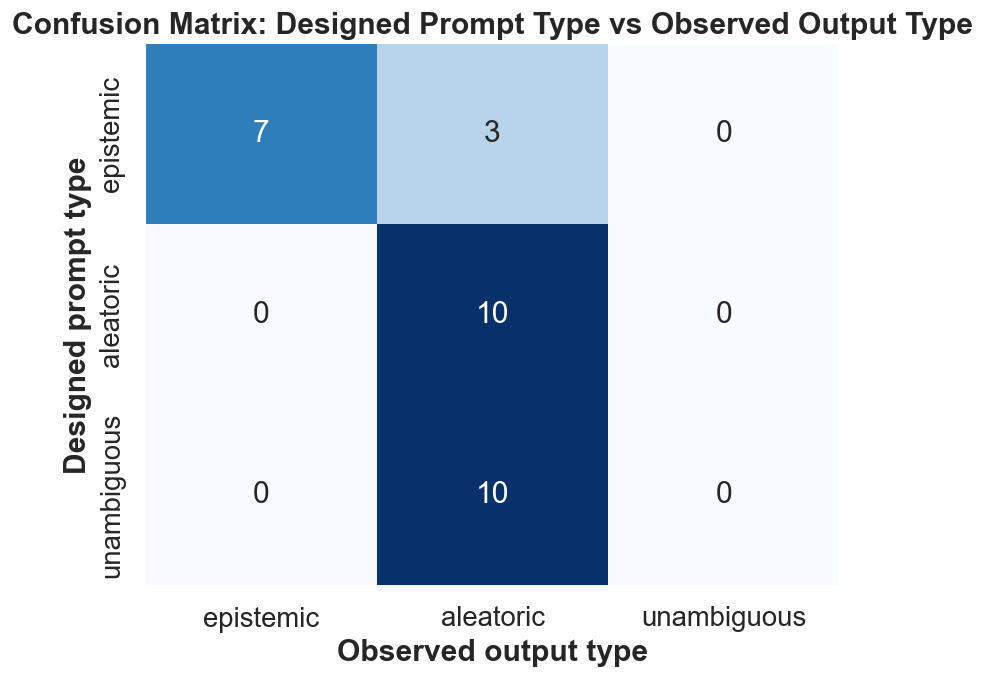

Observed output type,epistemic,aleatoric,unambiguous
Designed prompt type,,,
epistemic,7,3,0
aleatoric,0,10,0
unambiguous,0,10,0


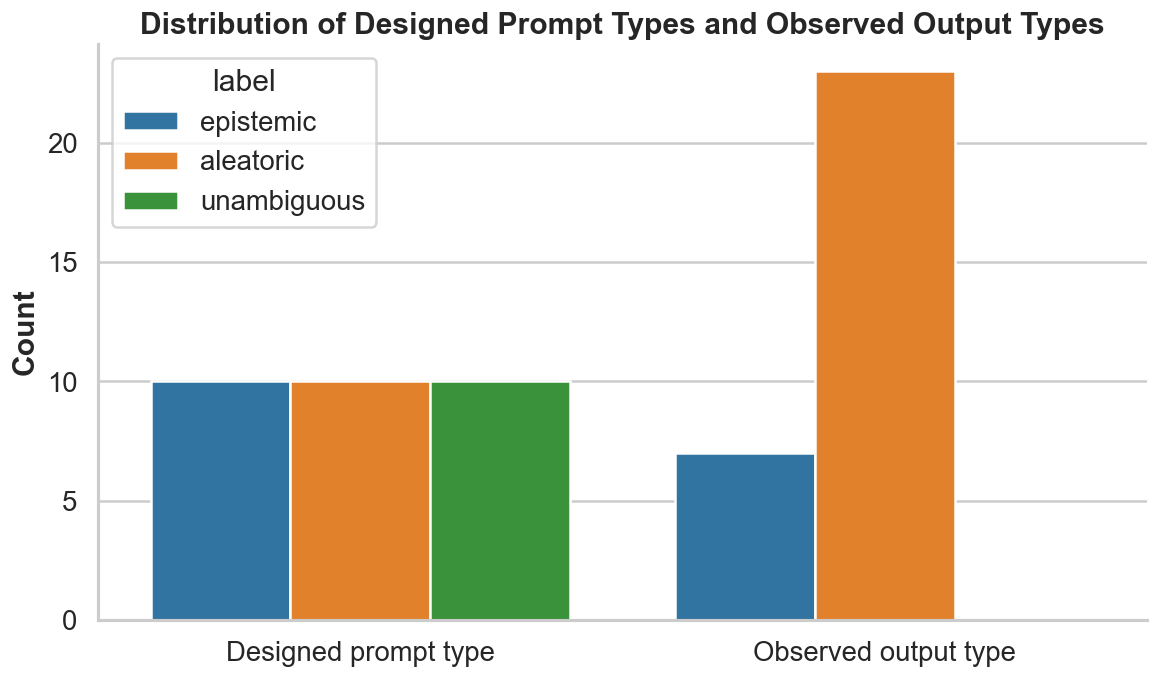

**Disagreement cases**

,prompt_id,prompt_text,prompt_type,generated_cq,manual_label,observed_output_type,variety
3,4,Summarise the key arguments in Harlow Pendleto...,epistemic,What aspects of Harlow Pendleton’s theory are ...,aleatoric,aleatoric,fabricated academic work
5,6,How does the Mossfield protocol differ from st...,epistemic,What aspects of the Mossfield protocol are you...,aleatoric,aleatoric,fabricated technical protocol
8,9,What is the population of Quelimares city in n...,epistemic,What is the current year you are asking about?,aleatoric,aleatoric,plausible but fabricated place
20,21,What is the capital of France?,unambiguous,Which country are you asking about?,aleatoric,aleatoric,basic factual — single definitive answer
21,22,How many planets are in the solar system?,unambiguous,What do you consider to be a planet?,aleatoric,aleatoric,basic factual — well established scientific co...
22,23,What does HTTP stand for?,unambiguous,What is the context of your question?,aleatoric,aleatoric,factual definition — single correct answer
23,24,In which year did World War II end?,unambiguous,"What definition of ""end"" are you asking about?",aleatoric,aleatoric,historical fact — single correct answer
24,25,What is the chemical formula for water?,unambiguous,What form of water are you asking about?,aleatoric,aleatoric,scientific fact — single correct answer
25,26,Who wrote Romeo and Juliet?,unambiguous,Who are you asking about?,aleatoric,aleatoric,attribution fact — single correct answer
26,27,What is the square root of 144?,unambiguous,What is the context of the question?,aleatoric,aleatoric,mathematical computation — single correct answer


C:\Users\dagxx\AppData\Local\Temp\ipykernel_17064\2449561152.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=labelled_df, x="observed_output_type", y="response_word_count", order=VALID_TYPES, palette=PALETTE, ax=ax)


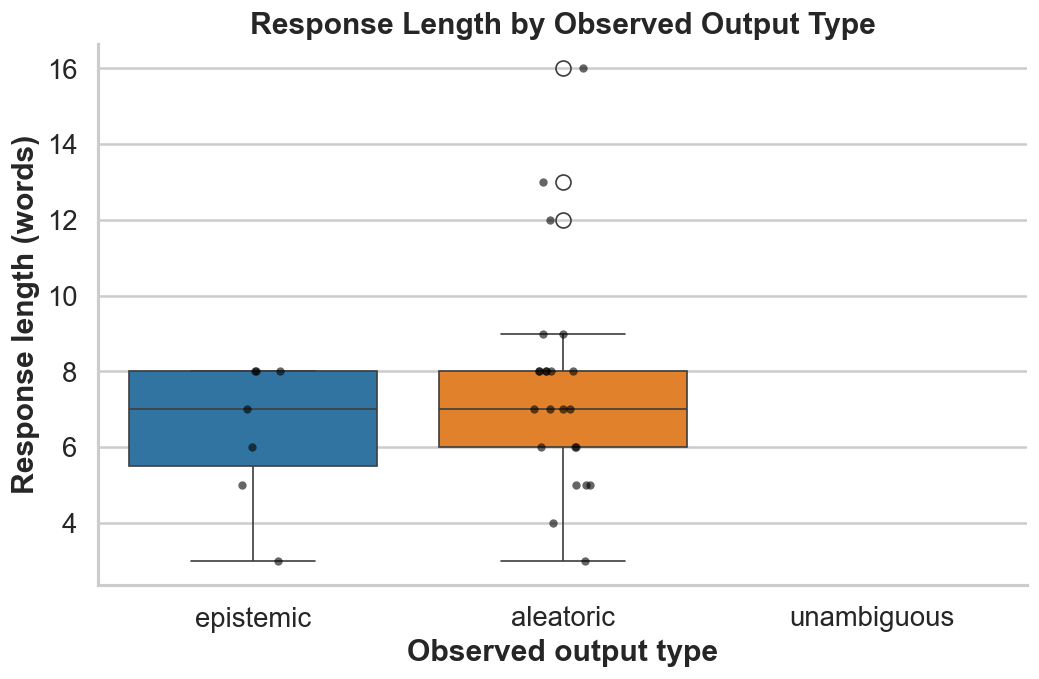

**Control accuracy** (`unambiguous` prompts returning `NO_CLARIFICATION_NEEDED`): 0.00%

C:\Users\dagxx\AppData\Local\Temp\ipykernel_17064\2449561152.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=control_summary, x="outcome", y="count", palette=PALETTE, ax=ax)


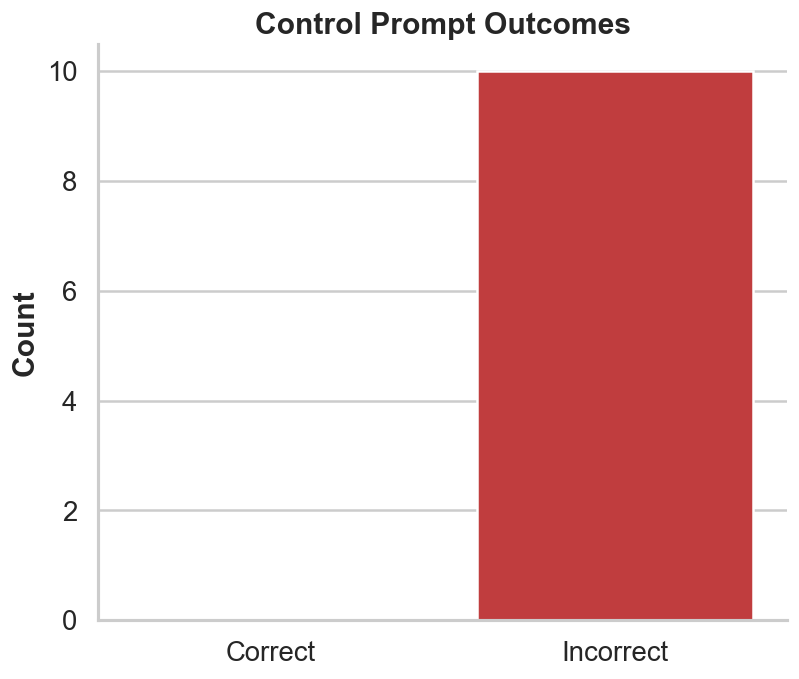

,prompt_id,prompt_text,generated_cq,manual_label,observed_output_type,returned_no_clarification
20,21,What is the capital of France?,Which country are you asking about?,aleatoric,aleatoric,False
21,22,How many planets are in the solar system?,What do you consider to be a planet?,aleatoric,aleatoric,False
22,23,What does HTTP stand for?,What is the context of your question?,aleatoric,aleatoric,False
23,24,In which year did World War II end?,"What definition of ""end"" are you asking about?",aleatoric,aleatoric,False
24,25,What is the chemical formula for water?,What form of water are you asking about?,aleatoric,aleatoric,False
25,26,Who wrote Romeo and Juliet?,Who are you asking about?,aleatoric,aleatoric,False
26,27,What is the square root of 144?,What is the context of the question?,aleatoric,aleatoric,False
27,28,What programming language is Python?,What do you want to know about Python?,aleatoric,aleatoric,False
28,29,How many sides does a hexagon have?,"What do you mean by ""sides""?",aleatoric,aleatoric,False
29,30,What is the speed of light in a vacuum?,What unit of measurement are you interested in?,aleatoric,aleatoric,False


In [7]:
agreement_rate = labelled_df["agreement"].mean()
display(Markdown(f"**Overall agreement rate between designed prompt type and observed output type:** {agreement_rate:.2%}"))

confusion = pd.crosstab(
    labelled_df["prompt_type"],
    labelled_df["observed_output_type"],
    rownames=["Designed prompt type"],
    colnames=["Observed output type"],
    dropna=False,
).reindex(index=VALID_TYPES, columns=VALID_TYPES, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Confusion Matrix: Designed Prompt Type vs Observed Output Type")
save_and_show(fig, "phase1_confusion_matrix.png")
display(confusion)

bar_df = labelled_df.melt(
    id_vars=["prompt_id"],
    value_vars=["prompt_type", "observed_output_type"],
    var_name="source",
    value_name="label",
)
bar_df["source"] = bar_df["source"].replace({
    "prompt_type": "Designed prompt type",
    "observed_output_type": "Observed output type",
})
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=bar_df, x="source", hue="label", hue_order=VALID_TYPES, palette=PALETTE, ax=ax)
ax.set_title("Distribution of Designed Prompt Types and Observed Output Types")
ax.set_xlabel("")
ax.set_ylabel("Count")
save_and_show(fig, "phase1_grouped_bar_labels_vs_types.png")

disagreement_columns = ["prompt_id", "prompt_text", "prompt_type", "generated_cq", "manual_label", "observed_output_type"]
if "variety" in labelled_df.columns:
    disagreement_columns.append("variety")
disagreements_df = labelled_df.loc[~labelled_df["agreement"], disagreement_columns]
display(Markdown("**Disagreement cases**"))
display(disagreements_df if not disagreements_df.empty else pd.DataFrame({"message": ["No disagreement cases found."]}))

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=labelled_df, x="observed_output_type", y="response_word_count", order=VALID_TYPES, palette=PALETTE, ax=ax)
sns.stripplot(data=labelled_df, x="observed_output_type", y="response_word_count", order=VALID_TYPES, color="black", alpha=0.6, ax=ax)
ax.set_title("Response Length by Observed Output Type")
ax.set_xlabel("Observed output type")
ax.set_ylabel("Response length (words)")
save_and_show(fig, "phase1_response_length_boxplot.png")

control_df = labelled_df[labelled_df["prompt_type"] == "unambiguous"].copy()
control_accuracy = control_df["returned_no_clarification"].mean()
display(Markdown(f"**Control accuracy** (`unambiguous` prompts returning `NO_CLARIFICATION_NEEDED`): {control_accuracy:.2%}"))
control_summary = pd.DataFrame({
    "outcome": ["Correct", "Incorrect"],
    "count": [int(control_df["returned_no_clarification"].sum()), int((~control_df["returned_no_clarification"]).sum())],
})
fig, ax = plt.subplots(figsize=(7, 6))
sns.barplot(data=control_summary, x="outcome", y="count", palette=PALETTE, ax=ax)
ax.set_title("Control Prompt Outcomes")
ax.set_xlabel("")
ax.set_ylabel("Count")
save_and_show(fig, "phase1_control_accuracy_bar.png")
display(control_df[[col for col in ["prompt_id", "prompt_text", "generated_cq", "manual_label", "observed_output_type", "returned_no_clarification"] if col in control_df.columns]])


# Phase 2 — Uncertainty Quantification

In [8]:
REGENERATE_PHASE2 = True

if VARIATION_RUNS_PATH.exists() and not REGENERATE_PHASE2:
    variation_runs_df = pd.read_csv(VARIATION_RUNS_PATH)
    variation_runs_df.columns = variation_runs_df.columns.astype(str).str.strip()
    variation_runs_df["prompt_id"] = variation_runs_df["prompt_id"].astype(str).map(clean_text)
else:
    variation_records = []
    total_jobs = len(prompts_df) * N_VARIATION_RUNS
    completed_jobs = 0
    for row in prompts_df.itertuples(index=False):
        for run_index in range(1, N_VARIATION_RUNS + 1):
            generated_cq = call_gemini_for_cq(row.prompt_text, generation_config=PHASE2_GENERATION_CONFIG)
            variation_records.append({
                "prompt_id": row.prompt_id,
                "run_index": run_index,
                "generated_cq": generated_cq,
            })
            completed_jobs += 1
            pd.DataFrame(variation_records).to_csv(VARIATION_RUNS_PATH, index=False)
            print(f"Generated variation run {completed_jobs}/{total_jobs}")
    variation_runs_df = pd.DataFrame(variation_records)
    variation_runs_df.to_csv(VARIATION_RUNS_PATH, index=False)

variation_runs_df["generated_cq"] = variation_runs_df["generated_cq"].fillna("").astype(str).map(clean_text)
display(variation_runs_df.head(15))


Generated variation run 1/150


Generated variation run 2/150


Generated variation run 3/150


Generated variation run 4/150


Generated variation run 5/150


...

Generated variation run 147/150


Generated variation run 148/150


Generated variation run 149/150


Generated variation run 150/150


,prompt_id,run_index,generated_cq
0,1,1,What industry does Kordemia operate in?
1,1,2,What industry does Kordemia operate in?
2,1,3,What industry does Kordemia operate in?
3,1,4,What industry does Kordemia operate in?
4,1,5,What industry does Kordemia operate in?
5,2,1,What is the context of the theorem's application?
6,2,2,What is the context of the theorem's application?
7,2,3,What is the context of the theorem's application?
8,2,4,What is the context of the theorem's application?
9,2,5,What is the context of the theorem's application?


In [9]:
pair_rows = []
for prompt_id, group in variation_runs_df.groupby("prompt_id", sort=True):
    run_records = group.sort_values("run_index").to_dict("records")
    if len(run_records) != N_VARIATION_RUNS:
        raise ValueError(f"Prompt {prompt_id} has {len(run_records)} variation runs; expected {N_VARIATION_RUNS}.")
    for left, right in itertools.combinations(run_records, 2):
        pair_rows.append({
            "prompt_id": prompt_id,
            "run_a": left["run_index"],
            "run_b": right["run_index"],
            "text_a": left["generated_cq"],
            "text_b": right["generated_cq"],
        })

pairwise_df = pd.DataFrame(pair_rows)
P, R, F1 = bertscore_score(pairwise_df["text_a"].tolist(), pairwise_df["text_b"].tolist(), lang="en", verbose=False)
pairwise_df["bertscore_f1"] = F1.detach().cpu().numpy()
pairwise_df["rougeL_f1"] = [rouge_l_f1(a, b) for a, b in zip(pairwise_df["text_a"], pairwise_df["text_b"])]

variation_scores_df = pairwise_df.groupby("prompt_id", as_index=False).agg(
    mean_bertscore=("bertscore_f1", "mean"),
    mean_rougeL=("rougeL_f1", "mean"),
)
variation_scores_df["mean_bertscore"] = variation_scores_df["mean_bertscore"].clip(lower=0.0, upper=1.0)
variation_scores_df["mean_rougeL"] = variation_scores_df["mean_rougeL"].clip(lower=0.0, upper=1.0)
variation_scores_df["variation_score"] = (1 - variation_scores_df["mean_bertscore"]).clip(lower=0.0, upper=1.0)
variation_scores_df.to_csv(VARIATION_SCORES_PATH, index=False)
display(variation_scores_df)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:  43%|████▎     | 169/389 [00:00<00:00, 1688.64it/s]

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 2458.40it/s]


RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,prompt_id,mean_bertscore,mean_rougeL,variation_score
0,1,1.000000,1.000000,0.000000e+00
1,10,1.000000,1.000000,1.192093e-07
2,11,1.000000,1.000000,0.000000e+00
3,12,0.995654,0.920000,4.346192e-03
4,13,1.000000,1.000000,1.192093e-07
5,14,1.000000,1.000000,0.000000e+00
6,15,1.000000,1.000000,0.000000e+00
7,16,1.000000,1.000000,0.000000e+00
8,17,1.000000,1.000000,0.000000e+00
9,18,1.000000,1.000000,1.788139e-07


## Phase 2 Analysis

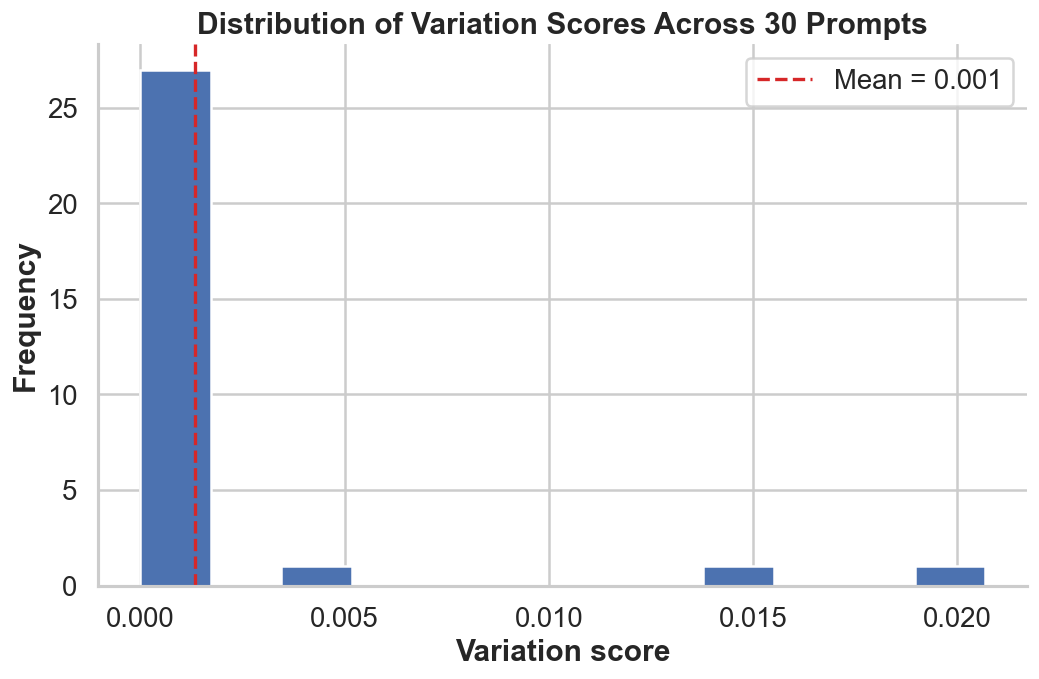

C:\Users\dagxx\AppData\Local\Temp\ipykernel_17064\918124187.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=variation_with_labels_df, x="prompt_type", y="variation_score", order=VALID_TYPES, palette=PALETTE, ax=axes[0])
C:\Users\dagxx\AppData\Local\Temp\ipykernel_17064\918124187.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=variation_with_labels_df, x="observed_output_type", y="variation_score", order=VALID_TYPES, palette=PALETTE, ax=axes[1])


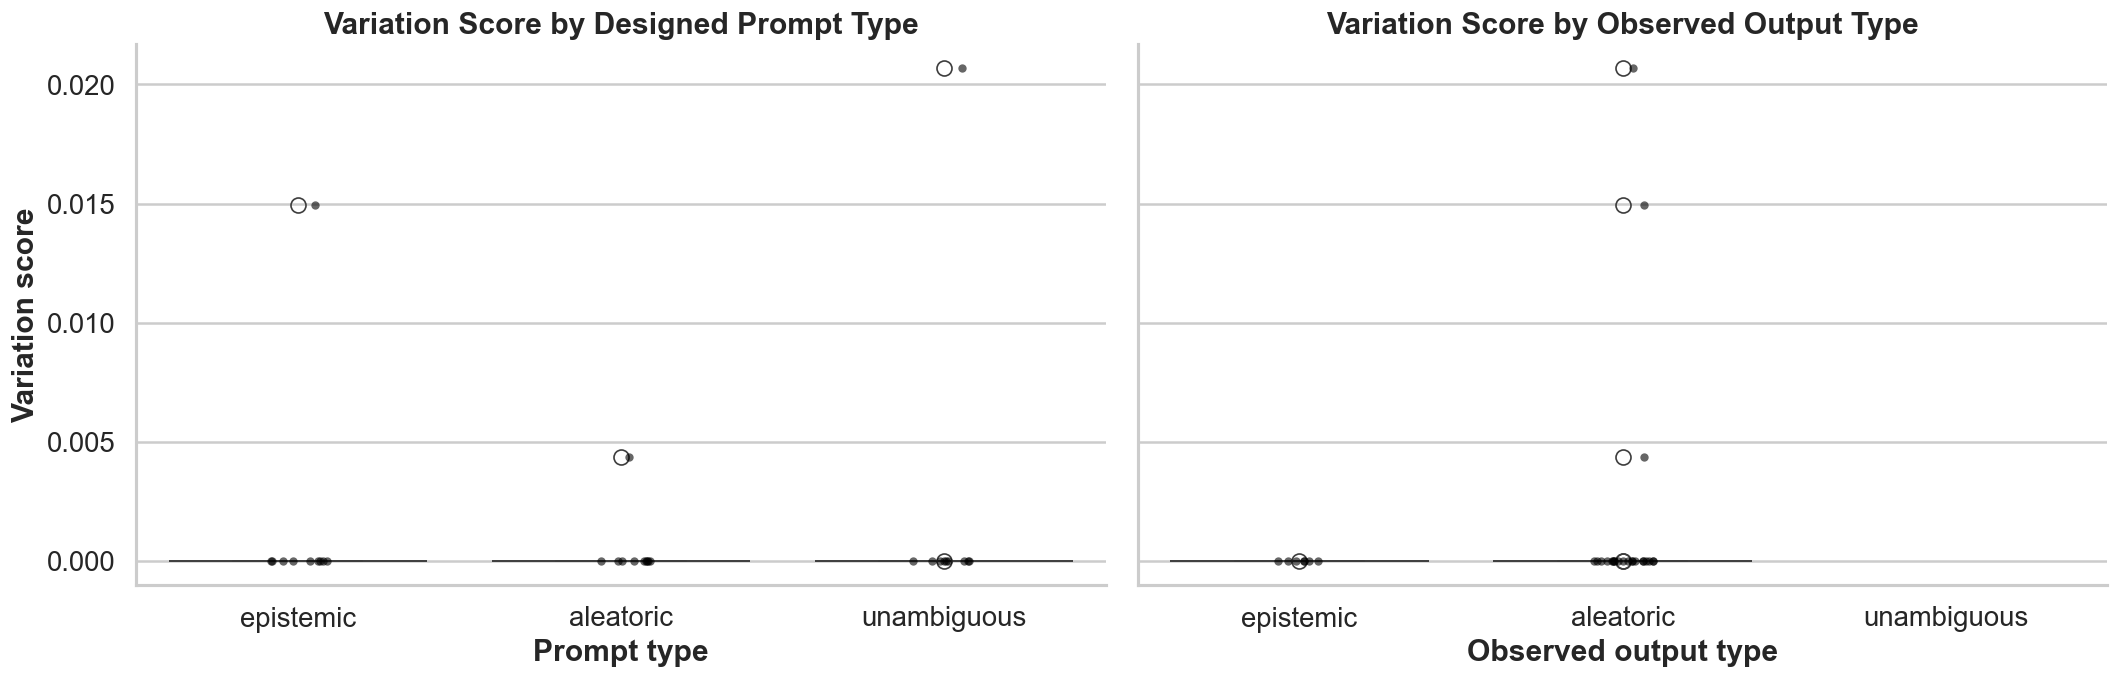

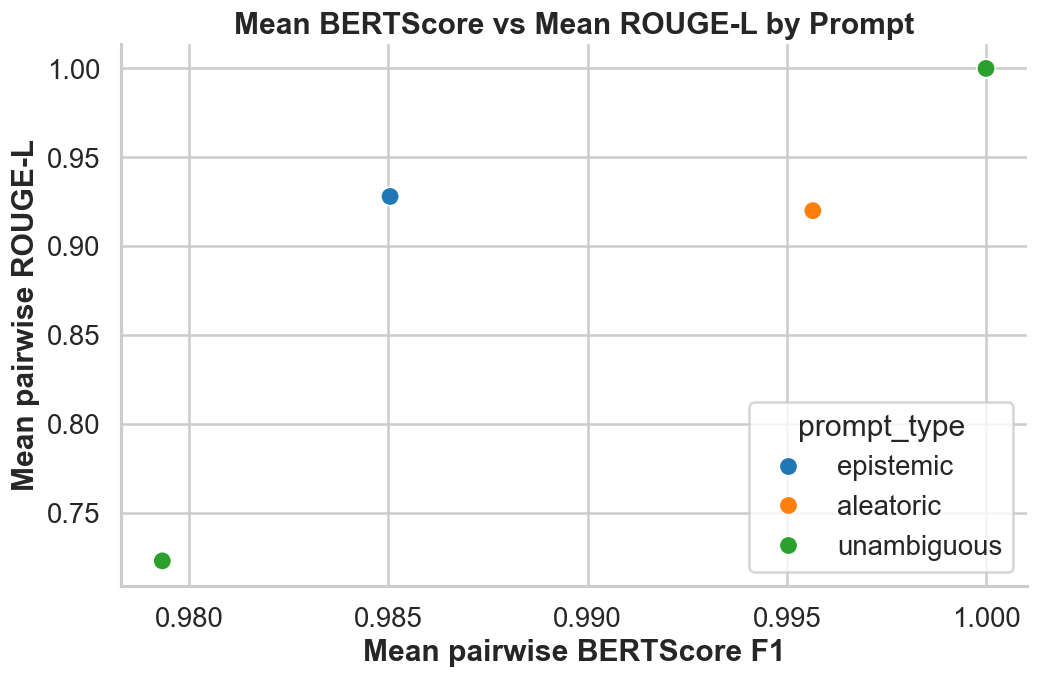

**Top 5 highest-variation prompts**

,prompt_id,prompt_text,prompt_type,variety,observed_output_type,variation_score,generated_cq
22,23,What does HTTP stand for?,unambiguous,factual definition — single correct answer,aleatoric,2.067268e-02,What is the context of your question?
3,4,Summarise the key arguments in Harlow Pendleto...,epistemic,fabricated academic work,aleatoric,1.495630e-02,What aspects of Harlow Pendleton’s theory are ...
11,12,How many goals did Messi score in the World Cup?,aleatoric,missing temporal context — multiple valid answ...,aleatoric,4.346192e-03,Which World Cups are you asking about?
1,2,Explain the Verlinden compression theorem and ...,epistemic,fabricated concept,epistemic,1.788139e-07,What is the context of the theorem's application?
17,18,What is the fastest route from here to the nea...,aleatoric,missing spatial context,aleatoric,1.788139e-07,Where are you currently located?


**Top 5 lowest-variation prompts**

,prompt_id,prompt_text,prompt_type,variety,observed_output_type,variation_score,generated_cq
0,1,What are the main export products of Kordemia?,epistemic,fabricated entity,epistemic,0.0,What industry does Kordemia operate in?
2,3,What programming language is the Drexel-9 micr...,epistemic,fabricated technical entity,epistemic,0.0,What is the Drexel-9 microprocessor?
5,6,How does the Mossfield protocol differ from st...,epistemic,fabricated technical protocol,aleatoric,0.0,What aspects of the Mossfield protocol are you...
4,5,What were the outcomes of the 2019 Tarethia cl...,epistemic,fabricated event,epistemic,0.0,What is Tarethia?
6,7,What is the boiling point of flerovium under s...,epistemic,real but obscure entity with unknown properties,epistemic,0.0,What standard atmospheric pressure are you ref...


In [10]:
variation_scores_df = pd.read_csv(VARIATION_SCORES_PATH)
variation_scores_df.columns = variation_scores_df.columns.astype(str).str.strip()
variation_scores_df["prompt_id"] = variation_scores_df["prompt_id"].astype(str).map(clean_text)
variation_enriched_df = prompts_df.merge(variation_scores_df, on="prompt_id", how="inner")
variation_with_labels_df = variation_enriched_df.merge(labelled_df[["prompt_id", "manual_label", "observed_output_type"]], on="prompt_id", how="left")

fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(variation_enriched_df["variation_score"], bins=12, color="#4c72b0", edgecolor="white")
mean_variation = variation_enriched_df["variation_score"].mean()
ax.axvline(mean_variation, color="#d62728", linestyle="--", linewidth=2, label=f"Mean = {mean_variation:.3f}")
ax.set_title("Distribution of Variation Scores Across 30 Prompts")
ax.set_xlabel("Variation score")
ax.set_ylabel("Frequency")
ax.legend()
save_and_show(fig, "phase2_variation_histogram.png")

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
sns.boxplot(data=variation_with_labels_df, x="prompt_type", y="variation_score", order=VALID_TYPES, palette=PALETTE, ax=axes[0])
sns.stripplot(data=variation_with_labels_df, x="prompt_type", y="variation_score", order=VALID_TYPES, color="black", alpha=0.6, ax=axes[0])
axes[0].set_title("Variation Score by Designed Prompt Type")
axes[0].set_xlabel("Prompt type")
axes[0].set_ylabel("Variation score")

sns.boxplot(data=variation_with_labels_df, x="observed_output_type", y="variation_score", order=VALID_TYPES, palette=PALETTE, ax=axes[1])
sns.stripplot(data=variation_with_labels_df, x="observed_output_type", y="variation_score", order=VALID_TYPES, color="black", alpha=0.6, ax=axes[1])
axes[1].set_title("Variation Score by Observed Output Type")
axes[1].set_xlabel("Observed output type")
axes[1].set_ylabel("Variation score")
save_and_show(fig, "phase2_variation_boxplots.png")

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=variation_enriched_df, x="mean_bertscore", y="mean_rougeL", hue="prompt_type", hue_order=VALID_TYPES, palette=PALETTE, s=120, ax=ax)
ax.set_title("Mean BERTScore vs Mean ROUGE-L by Prompt")
ax.set_xlabel("Mean pairwise BERTScore F1")
ax.set_ylabel("Mean pairwise ROUGE-L")
save_and_show(fig, "phase2_bertscore_vs_rougel_scatter.png")

variation_reading_df = variation_with_labels_df.merge(labelled_df[["prompt_id", "generated_cq"]], on="prompt_id", how="left")
reading_columns = [col for col in ["prompt_id", "prompt_text", "prompt_type", "variety", "observed_output_type", "variation_score", "generated_cq"] if col in variation_reading_df.columns]
display(Markdown("**Top 5 highest-variation prompts**"))
display(variation_reading_df.sort_values("variation_score", ascending=False).head(5)[reading_columns])
display(Markdown("**Top 5 lowest-variation prompts**"))
display(variation_reading_df.sort_values("variation_score", ascending=True).head(5)[reading_columns])


# Phase 3 — Correlation and Integration

In [11]:
final_df = labelled_df.merge(variation_scores_df, on="prompt_id", how="inner")
final_df["agreement"] = final_df["prompt_type"] == final_df["observed_output_type"]
final_df["agreement_label"] = final_df["agreement"].map({True: "Agreement", False: "Disagreement"})

binary_subset = final_df[final_df["manual_label"].isin(QUESTION_TYPES)].copy()
binary_subset["manual_label_binary"] = binary_subset["manual_label"].map({"aleatoric": 0, "epistemic": 1})
if binary_subset["manual_label_binary"].nunique() == 2:
    corr_result = pointbiserialr(binary_subset["manual_label_binary"], binary_subset["variation_score"])
    display(Markdown(
        f"**Point-biserial correlation** between `variation_score` and `manual_label` on the epistemic-vs-aleatoric subset (0 = aleatoric, 1 = epistemic): r = {corr_result.statistic:.3f}, p = {corr_result.pvalue:.4f}"
    ))
else:
    corr_result = None
    display(Markdown("**Point-biserial correlation** could not be computed because both epistemic and aleatoric manual label groups were not present after excluding the control condition."))

control_df = final_df[final_df["prompt_type"] == "unambiguous"].copy()
control_phase1_accuracy = control_df["returned_no_clarification"].mean()
control_variation_summary = control_df[["prompt_id", "variation_score", "generated_cq", "returned_no_clarification"]]
display(Markdown(f"**Control-group Phase 1 accuracy**: {control_phase1_accuracy:.2%} of unambiguous prompts correctly returned `NO_CLARIFICATION_NEEDED`."))
display(control_variation_summary)


**Point-biserial correlation** between `variation_score` and `manual_label` on the epistemic-vs-aleatoric subset (0 = aleatoric, 1 = epistemic): r = -0.162, p = 0.3920

**Control-group Phase 1 accuracy**: 0.00% of unambiguous prompts correctly returned `NO_CLARIFICATION_NEEDED`.

,prompt_id,variation_score,generated_cq,returned_no_clarification
20,21,0.000000e+00,Which country are you asking about?,False
21,22,0.000000e+00,What do you consider to be a planet?,False
22,23,2.067268e-02,What is the context of your question?,False
23,24,0.000000e+00,"What definition of ""end"" are you asking about?",False
24,25,0.000000e+00,What form of water are you asking about?,False
25,26,0.000000e+00,Who are you asking about?,False
26,27,1.788139e-07,What is the context of the question?,False
27,28,0.000000e+00,What do you want to know about Python?,False
28,29,0.000000e+00,"What do you mean by ""sides""?",False
29,30,0.000000e+00,What unit of measurement are you interested in?,False


### Plain-Language Interpretation

The point-biserial correlation is computed only on the **epistemic vs aleatoric subset**, because the `unambiguous` group is a control rather than one side of the uncertainty contrast. A positive correlation means epistemic-labelled cases tended to have higher variation scores than aleatoric-labelled cases; a negative correlation means the opposite. Values near zero indicate little linear association.


In [12]:
def run_mannwhitney(df: pd.DataFrame, label_column: str) -> dict:
    subset = df[df[label_column].isin(QUESTION_TYPES)].copy()
    epistemic_scores = subset.loc[subset[label_column] == "epistemic", "variation_score"]
    aleatoric_scores = subset.loc[subset[label_column] == "aleatoric", "variation_score"]
    result = mannwhitneyu(epistemic_scores, aleatoric_scores, alternative="two-sided")
    return {
        "grouping": label_column,
        "u_statistic": result.statistic,
        "p_value": result.pvalue,
        "n_epistemic": len(epistemic_scores),
        "n_aleatoric": len(aleatoric_scores),
    }


def run_kruskal(df: pd.DataFrame, label_column: str) -> dict:
    groups = [df.loc[df[label_column] == label, "variation_score"] for label in VALID_TYPES if (df[label_column] == label).any()]
    labels_present = [label for label in VALID_TYPES if (df[label_column] == label).any()]
    result = kruskal(*groups)
    return {
        "grouping": label_column,
        "labels_present": ", ".join(labels_present),
        "h_statistic": result.statistic,
        "p_value": result.pvalue,
    }


mannwhitney_results_df = pd.DataFrame([
    run_mannwhitney(final_df, "prompt_type"),
    run_mannwhitney(final_df, "manual_label"),
])
display(Markdown("**Mann-Whitney U test results (epistemic vs aleatoric only)**"))
display(mannwhitney_results_df)

kruskal_results_df = pd.DataFrame([
    run_kruskal(final_df, "prompt_type"),
    run_kruskal(final_df, "observed_output_type"),
])
display(Markdown("**Kruskal-Wallis results across all three prompt/output types**"))
display(kruskal_results_df)


**Mann-Whitney U test results (epistemic vs aleatoric only)**

,grouping,u_statistic,p_value,n_epistemic,n_aleatoric
0,prompt_type,50.5,1.00000,10,10
1,manual_label,79.0,0.94973,7,23


**Kruskal-Wallis results across all three prompt/output types**

,grouping,labels_present,h_statistic,p_value
0,prompt_type,"epistemic, aleatoric, unambiguous",0.157852,0.924108
1,observed_output_type,"epistemic, aleatoric",0.008943,0.924657


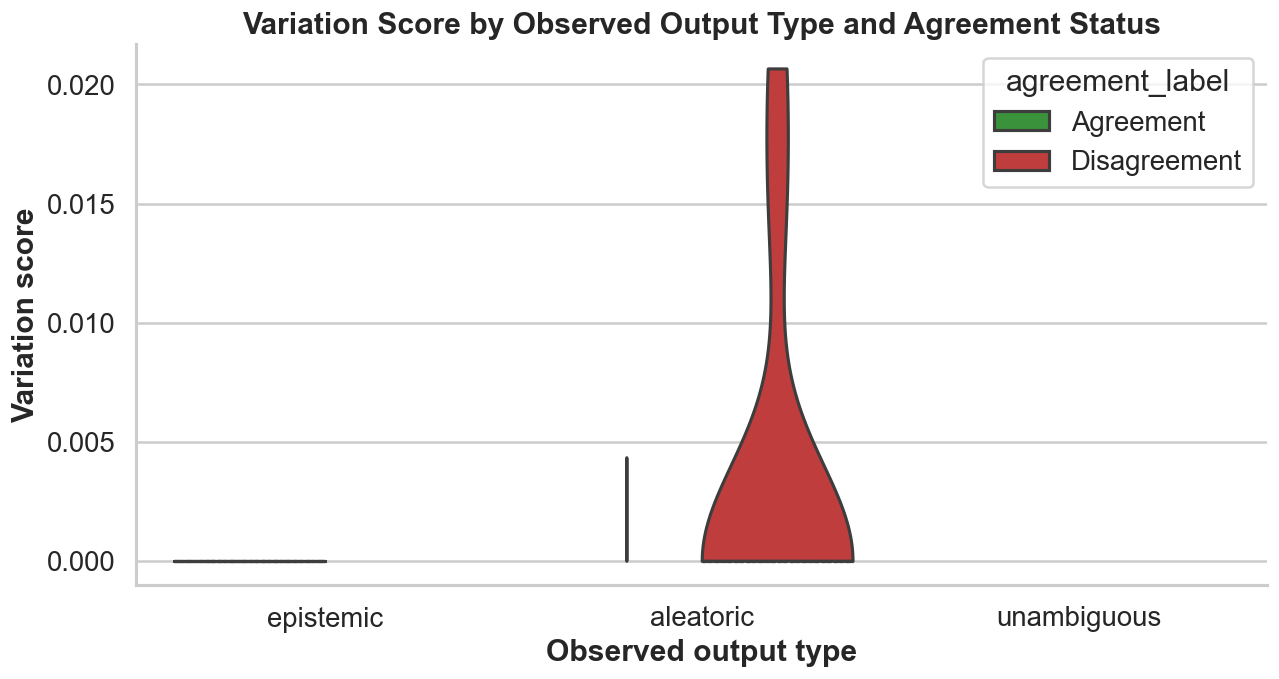

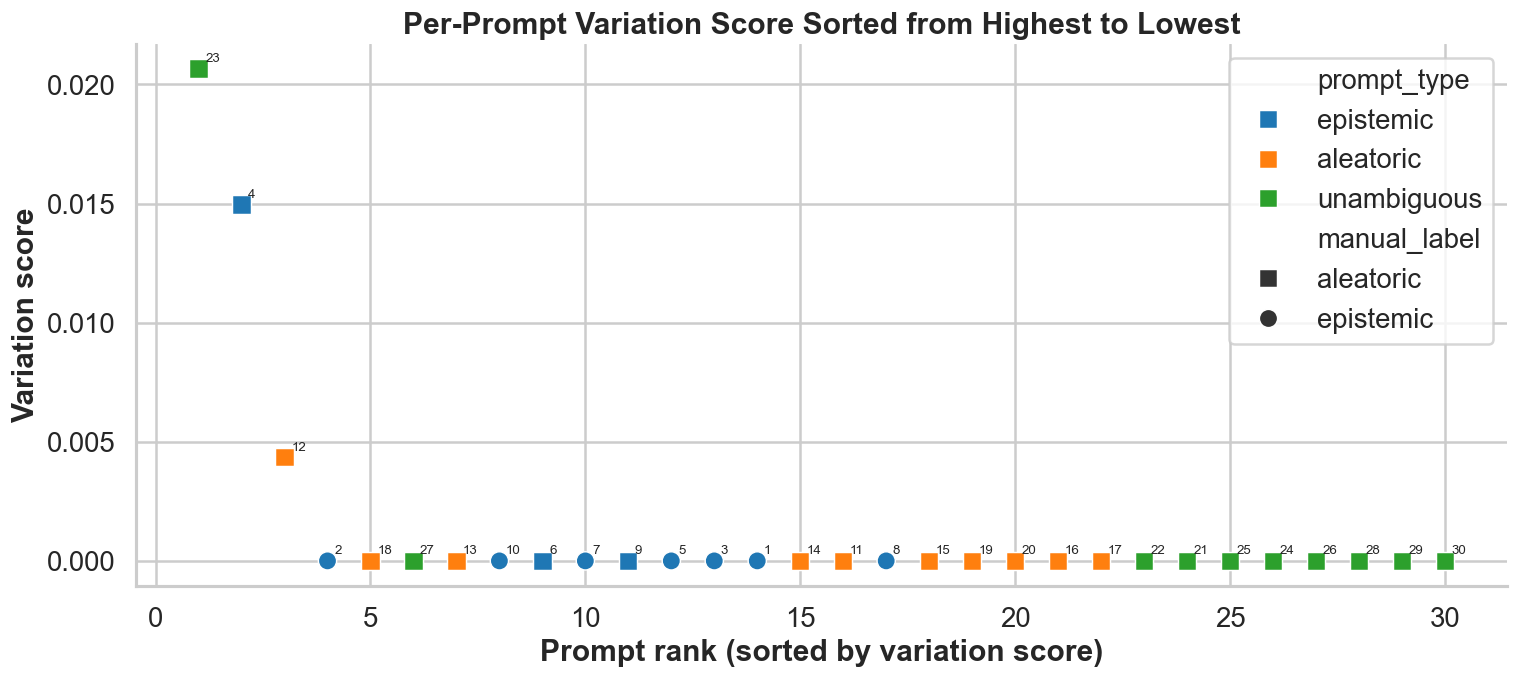

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.violinplot(data=final_df, x="observed_output_type", y="variation_score", hue="agreement_label", order=VALID_TYPES, palette=PALETTE, cut=0, inner="quartile", ax=ax)
ax.set_title("Variation Score by Observed Output Type and Agreement Status")
ax.set_xlabel("Observed output type")
ax.set_ylabel("Variation score")
save_and_show(fig, "phase3_violin_manual_label_agreement.png")

sorted_final_df = final_df.sort_values("variation_score", ascending=False).reset_index(drop=True).copy()
sorted_final_df["variation_rank"] = np.arange(1, len(sorted_final_df) + 1)
marker_map = {"epistemic": "o", "aleatoric": "s", "unambiguous": "^"}

fig, ax = plt.subplots(figsize=(13, 6))
sns.scatterplot(
    data=sorted_final_df,
    x="variation_rank",
    y="variation_score",
    hue="prompt_type",
    hue_order=VALID_TYPES,
    style="manual_label",
    palette=PALETTE,
    markers=marker_map,
    s=120,
    ax=ax,
)
ax.set_title("Per-Prompt Variation Score Sorted from Highest to Lowest")
ax.set_xlabel("Prompt rank (sorted by variation score)")
ax.set_ylabel("Variation score")
for row in sorted_final_df.itertuples(index=False):
    ax.annotate(row.prompt_id, (row.variation_rank, row.variation_score), textcoords="offset points", xytext=(4, 4), fontsize=8)
save_and_show(fig, "phase3_prompt_level_variation_scatter.png")


In [14]:
summary_columns = [col for col in [
    "prompt_id", "prompt_type", "manual_label", "observed_output_type", "agreement", "variation_score", "generated_cq", "variety"
] if col in final_df.columns]
summary_table = final_df[summary_columns].sort_values("variation_score", ascending=False)
display(Markdown("**Final summary table**"))
display(summary_table)


**Final summary table**

,prompt_id,prompt_type,manual_label,observed_output_type,agreement,variation_score,generated_cq,variety
22,23,unambiguous,aleatoric,aleatoric,False,2.067268e-02,What is the context of your question?,factual definition — single correct answer
3,4,epistemic,aleatoric,aleatoric,False,1.495630e-02,What aspects of Harlow Pendleton’s theory are ...,fabricated academic work
11,12,aleatoric,aleatoric,aleatoric,True,4.346192e-03,Which World Cups are you asking about?,missing temporal context — multiple valid answ...
1,2,epistemic,epistemic,epistemic,True,1.788139e-07,What is the context of the theorem's application?,fabricated concept
17,18,aleatoric,aleatoric,aleatoric,True,1.788139e-07,Where are you currently located?,missing spatial context
26,27,unambiguous,aleatoric,aleatoric,False,1.788139e-07,What is the context of the question?,mathematical computation — single correct answer
12,13,aleatoric,aleatoric,aleatoric,True,1.192093e-07,What genres do you typically enjoy reading?,missing personal preference context
9,10,epistemic,epistemic,epistemic,True,1.192093e-07,What beta blockers are you referring to?,fabricated drug name
5,6,epistemic,aleatoric,aleatoric,False,0.000000e+00,What aspects of the Mossfield protocol are you...,fabricated technical protocol
6,7,epistemic,epistemic,epistemic,True,0.000000e+00,What standard atmospheric pressure are you ref...,real but obscure entity with unknown properties


## Reflection Template

Use the prompts below to record your qualitative interpretation after reviewing the outputs.

### Did the labels feel natural to assign?

_Your notes here._

### Which cases were hardest to classify and why?

_Your notes here._

### Did epistemic and aleatoric prompts vary differently as hypothesised?

_Your notes here._

### How did the unambiguous control prompts behave?

_Your notes here._

### What does the correlation result suggest about the core research idea?

_Your notes here._

### Go or no-go for the full benchmark?

_Your notes here._
